# 10 - Verify Data Splits

This notebook verifies the quality and integrity of the data splits created by the `09_create_data_splits.ipynb` notebook.

**Verification Checks**:
1.  **Basic Statistics**: Calculate the number of samples, unique labels, and unique signers in each split (`train`, `val`, `test`).
2.  **Signer Overlap**: Programmatically confirm that there is zero overlap of `signer_id` between the splits. This is crucial for ensuring the model is tested on unseen individuals.
3.  **Class Distribution**: Visualize the percentage distribution of the top classes across the three splits to confirm that stratification was successful.
4.  **Signer Distribution**: Analyze the distribution of samples per signer within each split to check for any potential imbalances.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)
plt.style.use('ggplot')

In [2]:
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()

# This is the output file from notebook 09
INPUT_CSV = PROJECT_ROOT / 'merged_datasets' / 'universal_metadata_topn_with_splits.csv'

if not INPUT_CSV.exists():
    raise FileNotFoundError(f"Input file not found: {INPUT_CSV}\\nPlease run notebook '09_create_data_splits.ipynb' first.")

print('INPUT_CSV:', INPUT_CSV)

INPUT_CSV: C:\Users\Magda\source\repos\private\szum\merged_datasets\universal_metadata_topn_with_splits.csv


## 1. Load Data and Calculate Basic Statistics

In [3]:
df = pd.read_csv(INPUT_CSV)
print('Shape:', df.shape)

base = df[df['is_augmented'] == False] if 'is_augmented' in df.columns else df

split_stats = base.groupby('split').agg(
    n_samples        = ('label', 'count'),
    n_unique_labels  = ('label', 'nunique'),
    n_unique_signers = ('signer_id', 'nunique'),
).reset_index()
split_stats['sample_pct'] = (split_stats['n_samples'] / len(base) * 100).round(1)

print('\nSplit statistics (original clips):')
display(split_stats)

if 'is_augmented' in df.columns:
    train_orig = (df['split'].eq('train') & ~df['is_augmented']).sum()
    train_aug  = (df['split'].eq('train') &  df['is_augmented']).sum()
    print(f'\nTrain original: {train_orig}  |  Train after augmentation: {train_orig + train_aug}  (x{(train_orig + train_aug) / train_orig:.1f})')
    display(df.groupby(['split', 'is_augmented']).size().rename('rows'))

Shape: (3739, 29)

Split statistics (original clips):


,split,n_samples,n_unique_labels,n_unique_signers,sample_pct
0,test,61,41,6,16.1
1,train,280,50,28,73.9
2,val,38,29,4,10.0



Train original: 280  |  Train after augmentation: 3640  (x13.0)


split  is_augmented
test   False             61
train  False            280
       True            3360
val    False             38
Name: rows, dtype: int64

## 2. Verify Signer Overlap

This is the most critical check. We must ensure that the sets of signers in the `train`, `val`, and `test` splits are completely disjoint.

In [4]:
train_signers = set(base[base['split'] == 'train']['signer_id'].unique())
val_signers   = set(base[base['split'] == 'val'  ]['signer_id'].unique())
test_signers  = set(base[base['split'] == 'test' ]['signer_id'].unique())

print('Signer overlap check (original clips):')
print(f'  train: {len(train_signers)} signers')
print(f'  val:   {len(val_signers)} signers')
print(f'  test:  {len(test_signers)} signers')

overlap = {
    'train/val' : len(train_signers & val_signers),
    'train/test': len(train_signers & test_signers),
    'val/test'  : len(val_signers   & test_signers),
}
for pair, count in overlap.items():
    status = 'OK' if count == 0 else 'OVERLAP DETECTED'
    print(f'  {pair}: {count}  [{status}]')

if 'is_augmented' in df.columns:
    aug_in_val  = (df['split'].eq('val')  & df['is_augmented']).sum()
    aug_in_test = (df['split'].eq('test') & df['is_augmented']).sum()
    status = 'OK' if aug_in_val == 0 and aug_in_test == 0 else 'AUGMENTED SAMPLES FOUND'
    print(f'  augmented in val/test: {aug_in_val}/{aug_in_test}  [{status}]')

Signer overlap check (original clips):
  train: 28 signers
  val:   4 signers
  test:  6 signers
  train/val: 0  [OK]
  train/test: 0  [OK]
  val/test: 0  [OK]
  augmented in val/test: 0/0  [OK]


## 3. Analyze Class Distribution Across Splits

Let's visualize the distribution of the top N classes to visually confirm that stratification worked as expected. The percentages for each class should be roughly similar across `train`, `val`, and `test`.

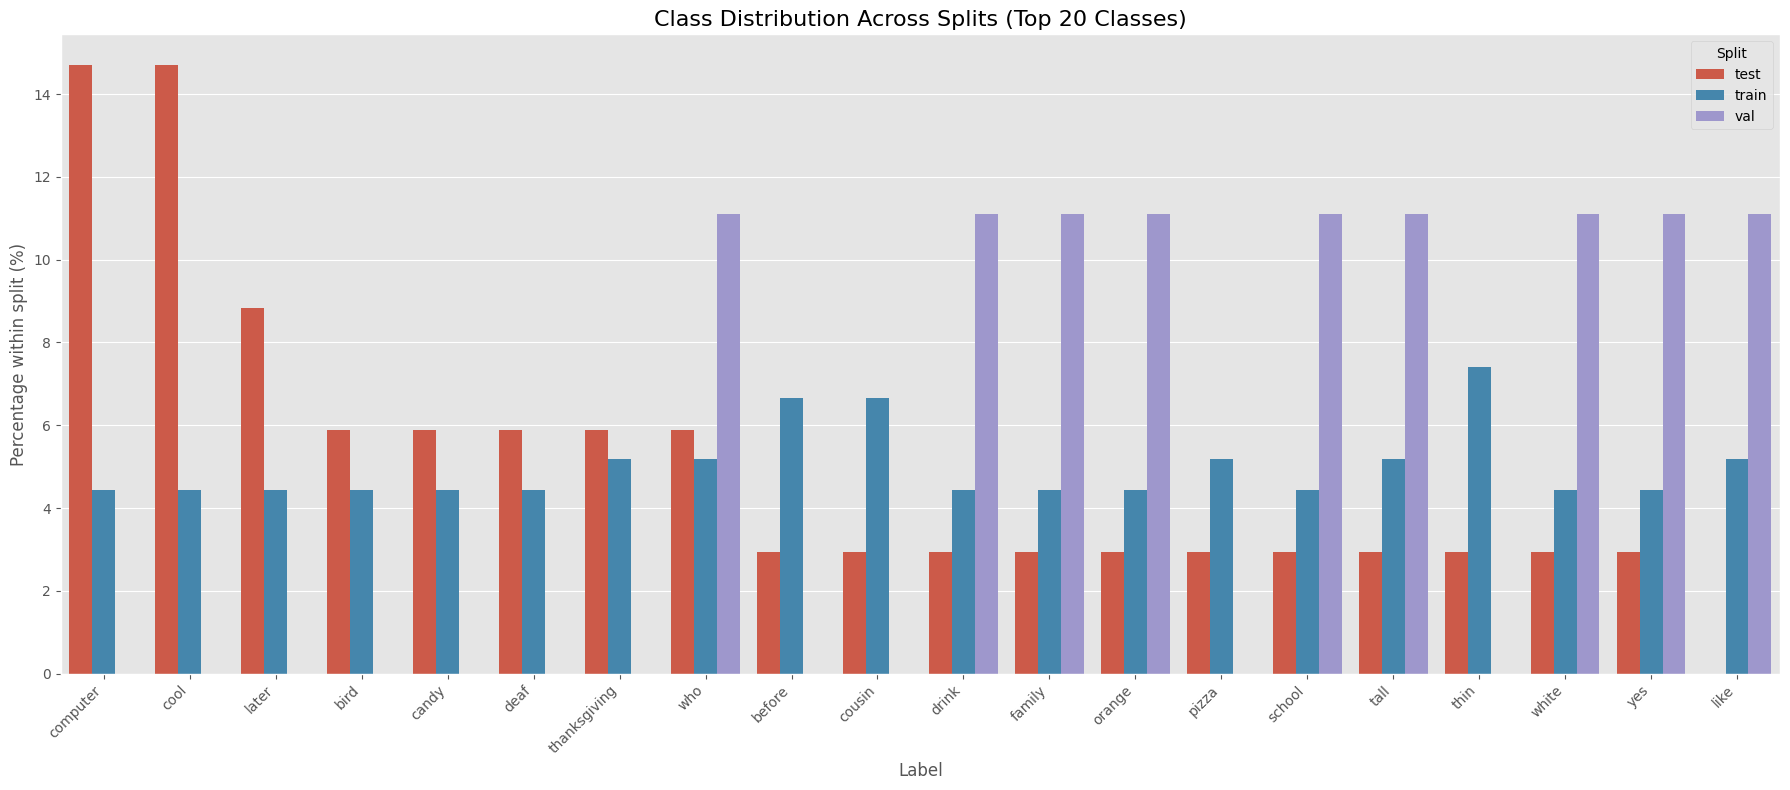

In [5]:
top_20_labels = df['label'].value_counts().nlargest(20).index
df_top = df[df['label'].isin(top_20_labels)]

class_dist = (df_top.groupby('split')['label']
              .value_counts(normalize=True)
              .mul(100)
              .rename('percentage')
              .reset_index())

plt.figure(figsize=(18, 8))
sns.barplot(x='label', y='percentage', hue='split', data=class_dist)
plt.title('Class Distribution Across Splits (Top 20 Classes)', fontsize=16)
plt.xlabel('Label', fontsize=12)
plt.ylabel('Percentage within split (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Split')
plt.tight_layout()
plt.show()

## 4. Analyze Signer Distribution

This analysis helps us understand if any single signer dominates a particular split. Ideally, the samples should be spread across many signers.

C:\Users\Magda\AppData\Local\Temp\ipykernel_8680\319685317.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=signer_counts.index, y=signer_counts.values, ax=ax, palette='viridis')
C:\Users\Magda\AppData\Local\Temp\ipykernel_8680\319685317.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=signer_counts.index, y=signer_counts.values, ax=ax, palette='viridis')
C:\Users\Magda\AppData\Local\Temp\ipykernel_8680\319685317.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=signer_counts.index, y=signer_counts.values, ax=ax, palette='vi

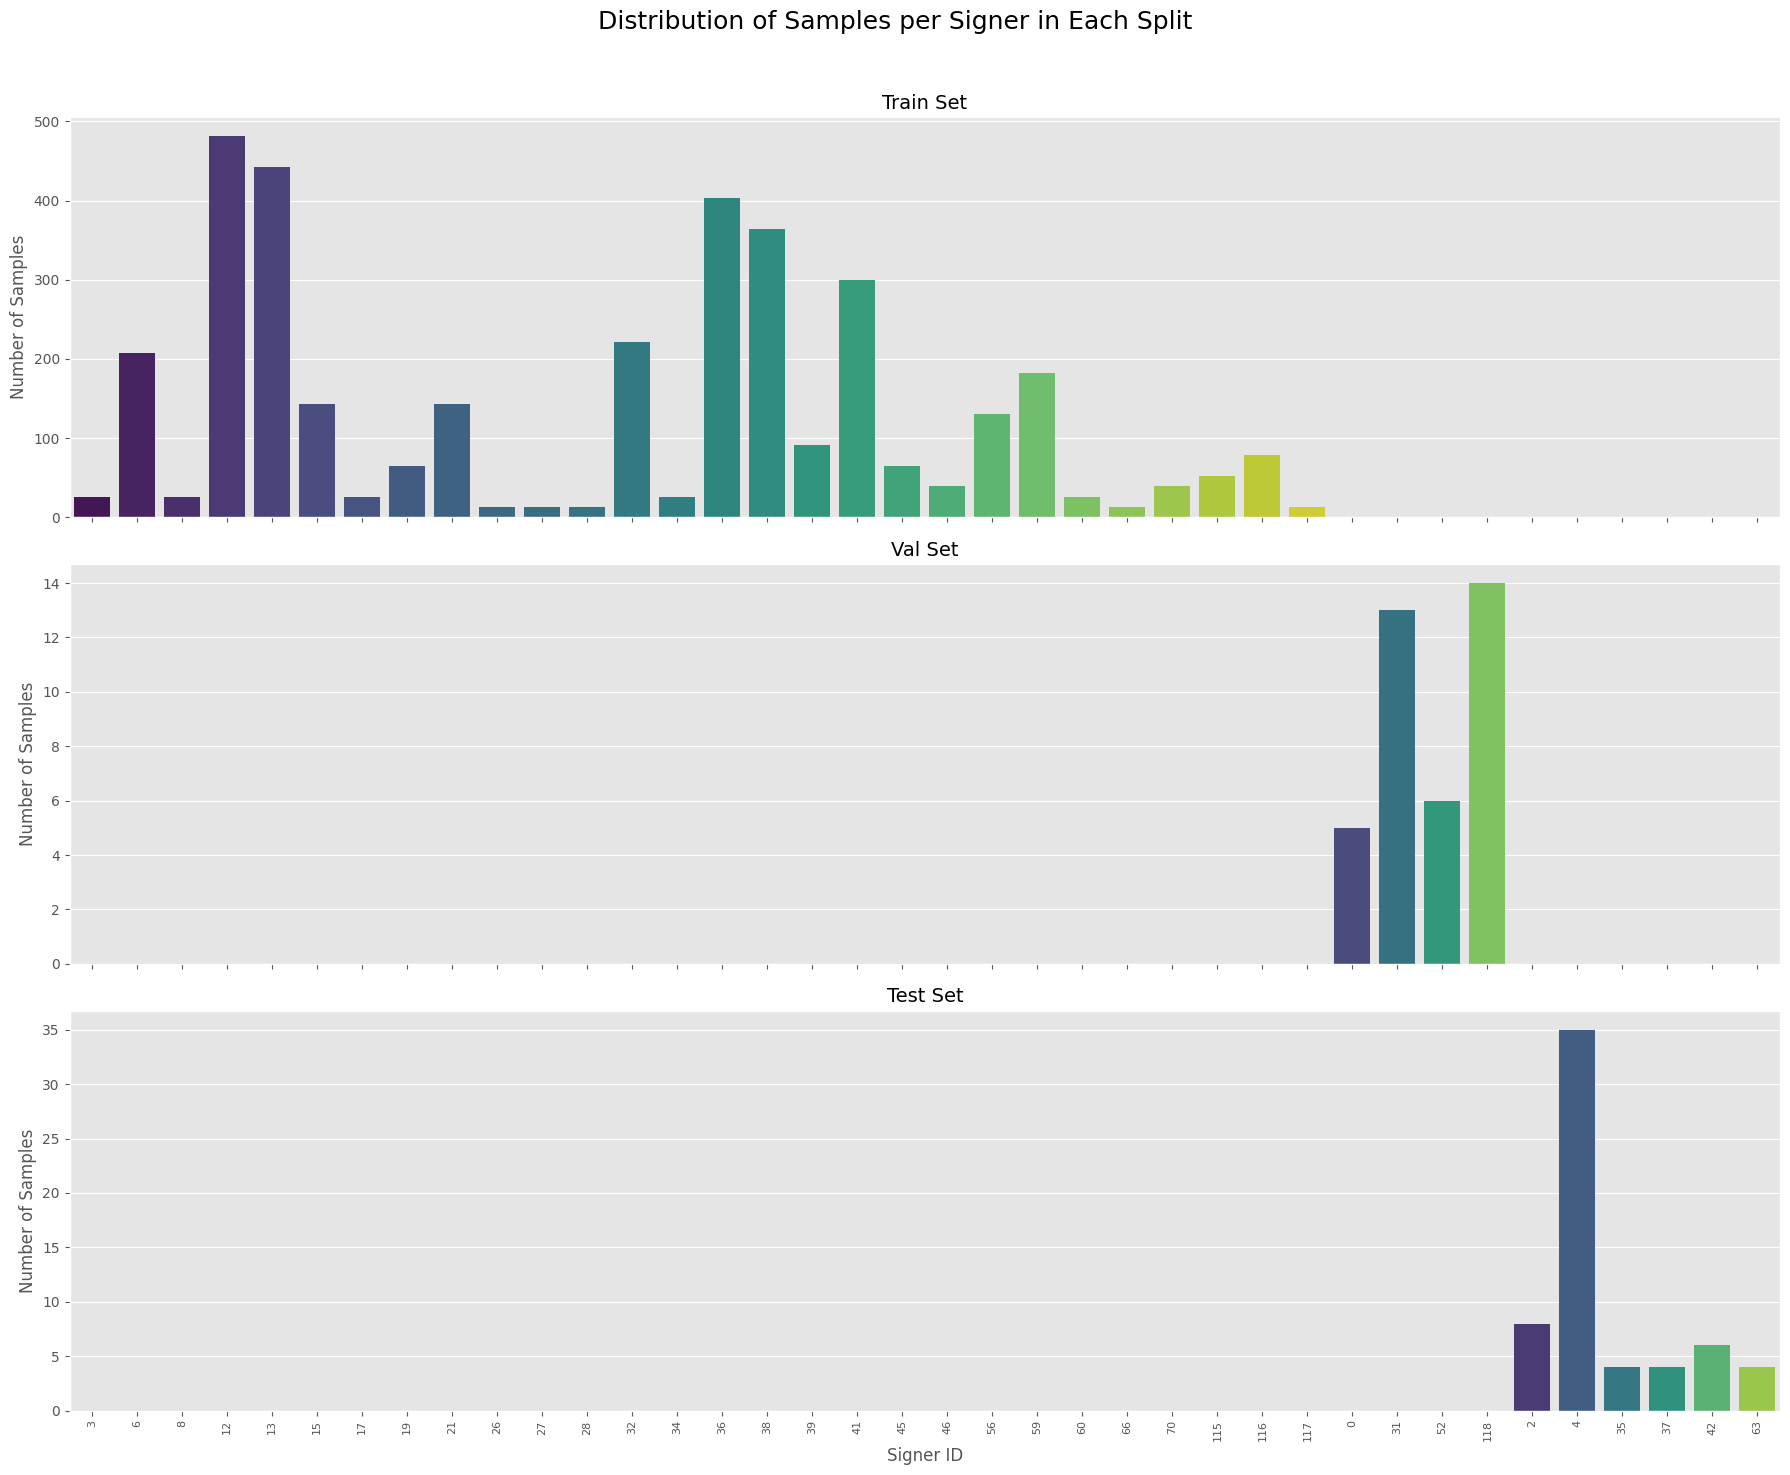

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(18, 15), sharex=True)
fig.suptitle('Distribution of Samples per Signer in Each Split', fontsize=18)

for i, split_name in enumerate(['train', 'val', 'test']):
    ax = axes[i]
    signer_counts = df[df['split'] == split_name]['signer_id'].value_counts().sort_values(ascending=False)

    if len(signer_counts) > 50:
        signer_counts = signer_counts.head(50)
        ax.set_title(f'{split_name.capitalize()} Set (Top 50 Signers)', fontsize=14)
    else:
        ax.set_title(f'{split_name.capitalize()} Set', fontsize=14)

    sns.barplot(x=signer_counts.index, y=signer_counts.values, ax=ax, palette='viridis')
    ax.set_ylabel('Number of Samples', fontsize=12)
    ax.tick_params(axis='x', rotation=90, labelsize=8)

axes[-1].set_xlabel('Signer ID', fontsize=12)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### Summary of Signer Distribution

Let's look at the descriptive statistics for the number of samples per signer in each split.

In [7]:
signer_dist_summary = df.groupby('split')['signer_id'].value_counts().groupby('split').describe()
display(signer_dist_summary)

,count,mean,std,min,25%,50%,75%,max
split,,,,,,,,
test,6.0,10.166667,12.270561,4.0,4.00,5.0,7.50,35.0
train,28.0,130.000000,143.196834,13.0,26.00,65.0,188.50,481.0
val,4.0,9.500000,4.654747,5.0,5.75,9.5,13.25,14.0
